In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
s = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])
print(s)
print(s['b'])      # access by label
print(s.values)     # underlying numpy array
print(s.index)      # the labels

a    10
b    20
c    30
d    40
dtype: int64
20
[10 20 30 40]
Index(['a', 'b', 'c', 'd'], dtype='str')


In [4]:
data = {
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [25, 30, 35, 28],
    "City": ["NYC", "LA", "Chicago", "Boston"],
    "Salary": [70000, 85000, 62000, 91000]
}

df = pd.DataFrame(data)
print(df)
print(df.shape)      # (rows, columns)
print(df.columns)    # column names
print(df.dtypes)     # data type of each column

      Name  Age     City  Salary
0    Alice   25      NYC   70000
1      Bob   30       LA   85000
2  Charlie   35  Chicago   62000
3    David   28   Boston   91000
(4, 4)
Index(['Name', 'Age', 'City', 'Salary'], dtype='str')
Name        str
Age       int64
City        str
Salary    int64
dtype: object


In [5]:
print(df.head(2))     # first 2 rows
print(df.tail(2))     # last 2 rows
print(df.info())      # summary: types, nulls, memory
print(df.describe())  # statistics: mean, std, min, max for numeric cols

    Name  Age City  Salary
0  Alice   25  NYC   70000
1    Bob   30   LA   85000
      Name  Age     City  Salary
2  Charlie   35  Chicago   62000
3    David   28   Boston   91000
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    4 non-null      str  
 1   Age     4 non-null      int64
 2   City    4 non-null      str  
 3   Salary  4 non-null      int64
dtypes: int64(2), str(2)
memory usage: 260.0 bytes
None
             Age        Salary
count   4.000000      4.000000
mean   29.500000  77000.000000
std     4.203173  13341.664064
min    25.000000  62000.000000
25%    27.250000  68000.000000
50%    29.000000  77500.000000
75%    31.250000  86500.000000
max    35.000000  91000.000000


In [6]:
df.to_csv("../../files/sample_data.csv", index=False)
print("CSV saved!")

CSV saved!


In [7]:
# .loc — by label
print(df.loc[0])              # row with index label 0
print(df.loc[0, 'Name'])      # specific cell
print(df.loc[0:2, 'Name'])    # rows 0 to 2, Name column

# .iloc — by position
print(df.iloc[0])             # first row (position 0)
print(df.iloc[0, 0])          # row 0, col 0
print(df.iloc[0:2, 0:2])      # first 2 rows, first 2 cols

Name      Alice
Age          25
City        NYC
Salary    70000
Name: 0, dtype: object
Alice
0      Alice
1        Bob
2    Charlie
Name: Name, dtype: str
Name      Alice
Age          25
City        NYC
Salary    70000
Name: 0, dtype: object
Alice
    Name  Age
0  Alice   25
1    Bob   30


In [8]:
# Single condition
high_earners = df[df['Salary'] > 70000]
print(high_earners)

# Multiple conditions (use & and |, wrap each in parentheses)
result = df[(df['Salary'] > 60000) & (df['Age'] < 30)]
print(result)

# Filter by string match
nyc_people = df[df['City'] == 'NYC']
print(nyc_people)

# isin() for multiple values
selected_cities = df[df['City'].isin(['NYC', 'LA'])]
print(selected_cities)

    Name  Age    City  Salary
1    Bob   30      LA   85000
3  David   28  Boston   91000
    Name  Age    City  Salary
0  Alice   25     NYC   70000
3  David   28  Boston   91000
    Name  Age City  Salary
0  Alice   25  NYC   70000
    Name  Age City  Salary
0  Alice   25  NYC   70000
1    Bob   30   LA   85000


In [9]:
print(df['Name'])               # single column (Series)
print(df[['Name', 'Salary']])   # multiple columns (DataFrame)

0      Alice
1        Bob
2    Charlie
3      David
Name: Name, dtype: str
      Name  Salary
0    Alice   70000
1      Bob   85000
2  Charlie   62000
3    David   91000


In [10]:
df['Bonus'] = df['Salary'] * 0.1
print(df)

df['Senior'] = df['Age'] > 30
print(df)

      Name  Age     City  Salary   Bonus
0    Alice   25      NYC   70000  7000.0
1      Bob   30       LA   85000  8500.0
2  Charlie   35  Chicago   62000  6200.0
3    David   28   Boston   91000  9100.0
      Name  Age     City  Salary   Bonus  Senior
0    Alice   25      NYC   70000  7000.0   False
1      Bob   30       LA   85000  8500.0   False
2  Charlie   35  Chicago   62000  6200.0    True
3    David   28   Boston   91000  9100.0   False


In [11]:
# Titanic dataset — classic ML beginner dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

print(titanic.shape)
print(titanic.head())
print(titanic.info())
print(titanic.describe())

# Filter — survivors only
survivors = titanic[titanic['Survived'] == 1]
print("Survivors:", len(survivors))

# Filter — female passengers in first class
women_first_class = titanic[(titanic['Sex'] == 'female') & (titanic['Pclass'] == 1)]
print("Women in 1st class:", len(women_first_class))

# Average age by passenger class
print(titanic.groupby('Pclass')['Age'].mean())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

=== Survival Rate by Class ===
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

=== Survival Rate by Gender ===
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

=== Survival Rate by Family Size ===
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

=== Survival Rate by Title ===
Title
Lady            1.000000
Ms              1.000000
Sir             1.000000
Mme             1.000000
the Countess    1.000000
Mlle            1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Major           0.500000
Col             0.500000
Dr              0.428571
Mr              0.156673
Capt            0.000000
Jonkheer        0.000000
Don             0.000000
Rev             0.000000
Name: Survived, dtype: float64


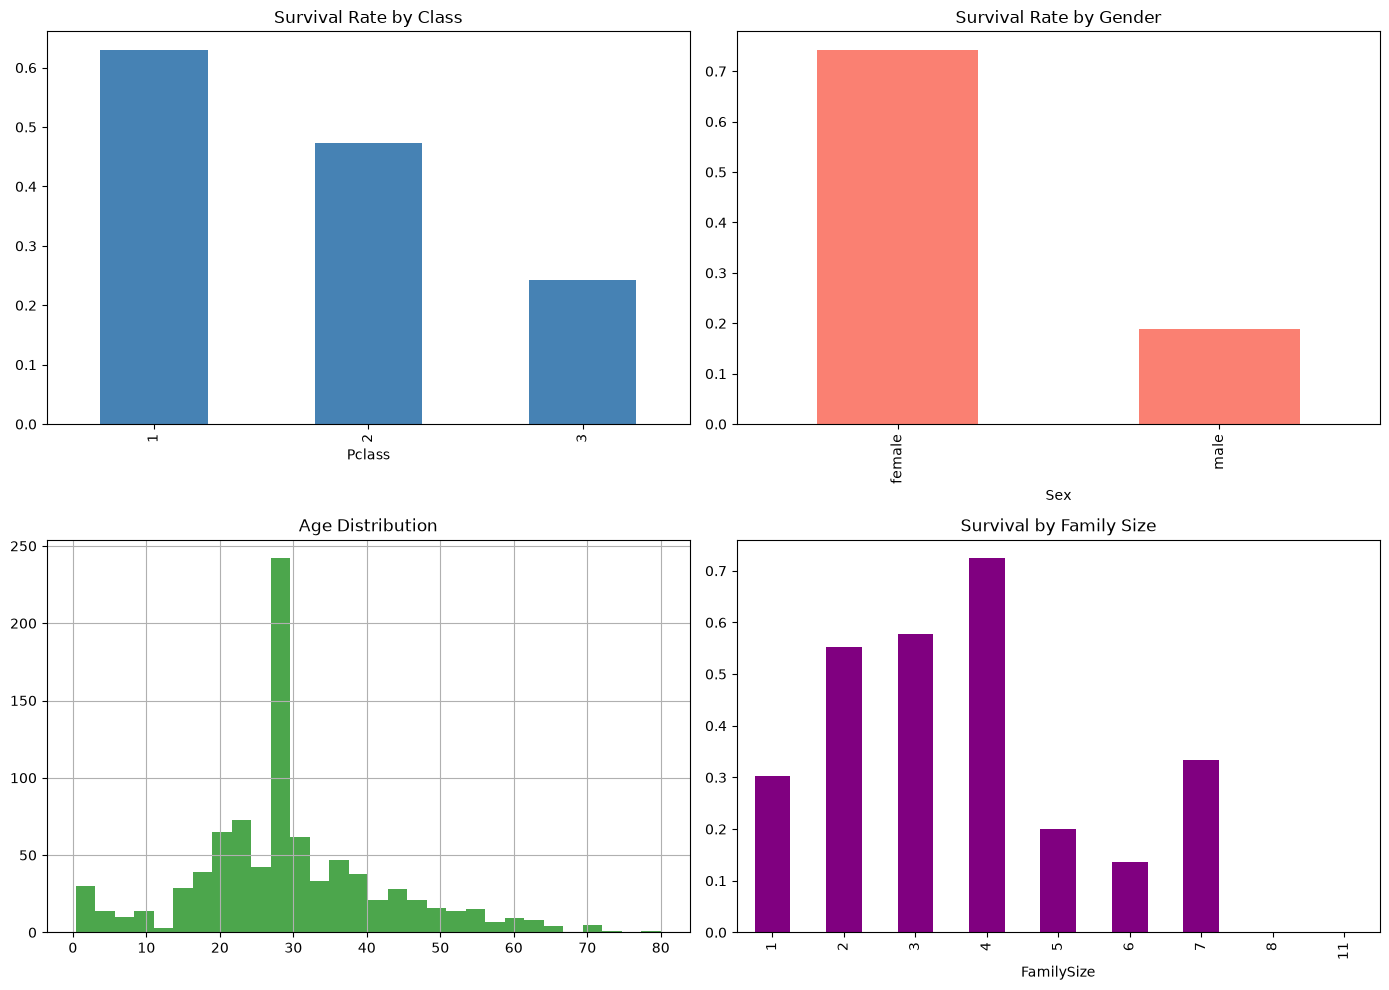

In [12]:
# Step 1: Load and clean
titanic = pd.read_csv(url)
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic = titanic.drop(columns=['Cabin'])  # too many missing values

# Step 2: Feature engineering
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic['IsAlone'] = (titanic['FamilySize'] == 1).astype(int)
titanic['Title'] = titanic['Name'].str.extract(r',\s*([^\.]*)\.')

# Step 3: Survival analysis
print("=== Survival Rate by Class ===")
print(titanic.groupby('Pclass')['Survived'].mean())

print("\n=== Survival Rate by Gender ===")
print(titanic.groupby('Sex')['Survived'].mean())

print("\n=== Survival Rate by Family Size ===")
print(titanic.groupby('FamilySize')['Survived'].mean())

print("\n=== Survival Rate by Title ===")
print(titanic.groupby('Title')['Survived'].mean().sort_values(ascending=False))

# Step 4: Visualize key findings
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titanic.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Survival Rate by Class')

titanic.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title('Survival Rate by Gender')

titanic['Age'].hist(bins=30, ax=axes[1,0], color='green', alpha=0.7)
axes[1,0].set_title('Age Distribution')

titanic.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Survival by Family Size')

plt.tight_layout()
plt.savefig("../../assets/images/titanic_eda.png", dpi=150, bbox_inches='tight')
plt.show()

            timestamp  server  status_code  response_time_ms  cpu_percent
0 2026-01-01 00:00:00  srv-03          200        105.918877    57.279460
1 2026-01-01 00:05:00  srv-01          200         40.393821    26.924947
2 2026-01-01 00:10:00  srv-03          500         78.193170    53.818946
3 2026-01-01 00:15:00  srv-03          404         67.979047    61.283905
4 2026-01-01 00:20:00  srv-01          503          8.504221    47.900937
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         1000 non-null   datetime64[us]
 1   server            1000 non-null   str           
 2   status_code       1000 non-null   int64         
 3   response_time_ms  1000 non-null   float64       
 4   cpu_percent       1000 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 39.2 KB
None



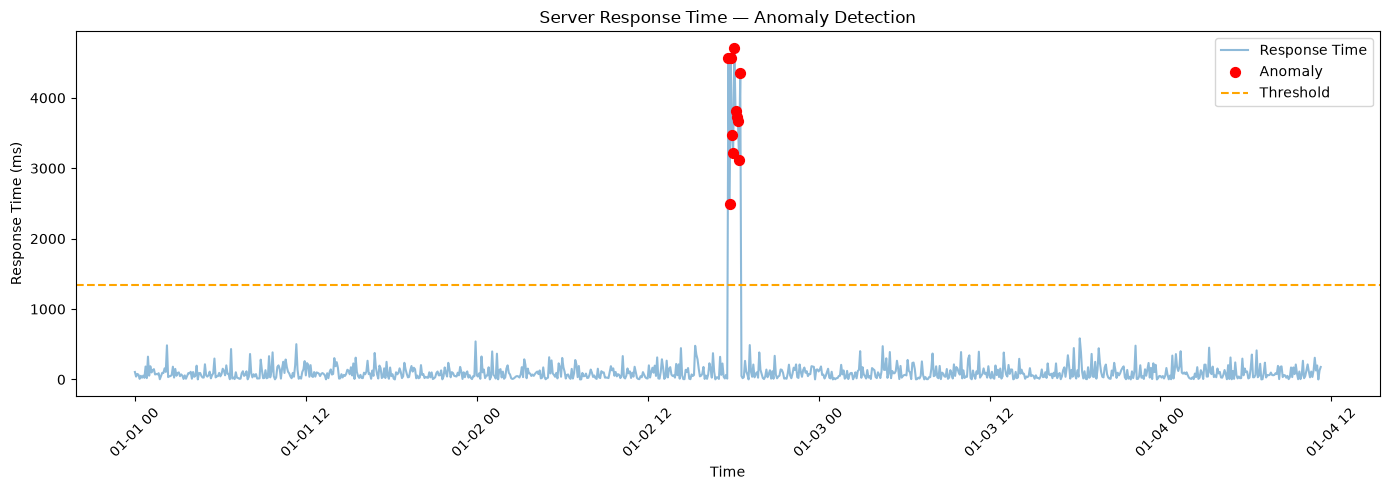

In [13]:
# Generate fake server log data
np.random.seed(42)
n = 1000

logs = pd.DataFrame({
    'timestamp': pd.date_range('2026-01-01', periods=n, freq='5min'),
    'server': np.random.choice(['srv-01', 'srv-02', 'srv-03'], n),
    'status_code': np.random.choice([200, 200, 200, 404, 500, 503], n),
    'response_time_ms': np.random.exponential(scale=100, size=n),
    'cpu_percent': np.random.normal(45, 15, n).clip(0, 100)
})

# Inject some anomalies
logs.loc[500:510, 'response_time_ms'] = np.random.uniform(2000, 5000, 11)
logs.loc[500:510, 'status_code'] = 503

print(logs.head())
print(logs.info())

# Error rate per server
error_logs = logs[logs['status_code'] >= 400]
print("\n=== Error Rate by Server ===")
print(error_logs.groupby('server').size() / logs.groupby('server').size() * 100)

# Average response time per hour
logs['hour'] = logs['timestamp'].dt.hour
print("\n=== Avg Response Time by Hour ===")
print(logs.groupby('hour')['response_time_ms'].mean())

# Find anomalous spikes (response time > mean + 3*std)
threshold = logs['response_time_ms'].mean() + 3 * logs['response_time_ms'].std()
anomalies = logs[logs['response_time_ms'] > threshold]
print(f"\n=== Anomalies Detected: {len(anomalies)} ===")
print(anomalies[['timestamp', 'server', 'status_code', 'response_time_ms']])

# Visualize
plt.figure(figsize=(14, 5))
plt.plot(logs['timestamp'], logs['response_time_ms'], alpha=0.5, label='Response Time')
plt.scatter(anomalies['timestamp'], anomalies['response_time_ms'], color='red', s=50, label='Anomaly', zorder=5)
plt.axhline(y=threshold, color='orange', linestyle='--', label='Threshold')
plt.title("Server Response Time — Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Response Time (ms)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../assets/images/server_anomalies.png", dpi=150, bbox_inches='tight')
plt.show()

month
December     51339.020386
November     49876.739939
October      49028.072155
August       45598.662963
September    45399.899981
July         43571.792450
May          40375.914439
June         39899.067154
April        36002.997628
March        35972.604272
January      32032.369072
February     30702.354700
Name: sales, dtype: float64
is_weekend
False    1368.446156
True     1371.490851
Name: sales, dtype: float64


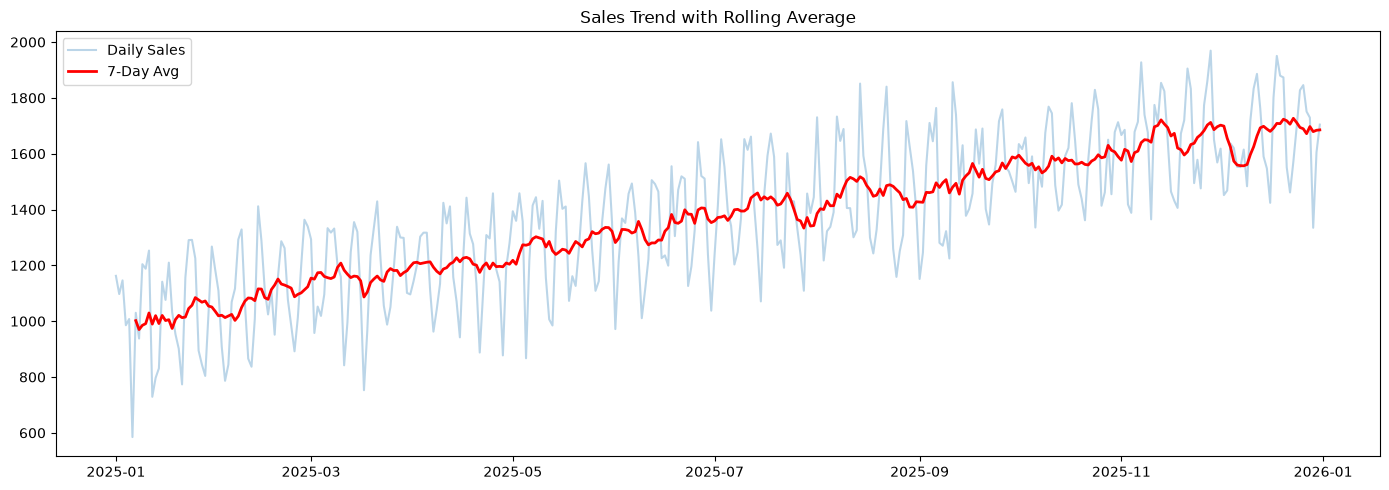

In [14]:
np.random.seed(1)
dates = pd.date_range('2025-01-01', periods=365, freq='D')
sales = pd.DataFrame({
    'date': dates,
    'sales': 1000 + np.arange(365) * 2 + np.random.normal(0, 100, 365) + 
             200 * np.sin(np.arange(365) * 2 * np.pi / 7)  # weekly pattern
})

sales['day_of_week'] = sales['date'].dt.day_name()
sales['month'] = sales['date'].dt.month_name()
sales['is_weekend'] = sales['date'].dt.dayofweek >= 5

# Monthly totals
print(sales.groupby('month')['sales'].sum().sort_values(ascending=False))

# Weekday vs weekend average
print(sales.groupby('is_weekend')['sales'].mean())

# Rolling 7-day average (smoothing trend)
sales['rolling_avg'] = sales['sales'].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
plt.plot(sales['date'], sales['sales'], alpha=0.3, label='Daily Sales')
plt.plot(sales['date'], sales['rolling_avg'], color='red', linewidth=2, label='7-Day Avg')
plt.title("Sales Trend with Rolling Average")
plt.legend()
plt.tight_layout()
plt.savefig("../../assets/images/sales_trend.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
customers = pd.DataFrame({
    'customer_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'segment': ['Premium', 'Standard', 'Premium', 'Standard']
})

orders = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105],
    'customer_id': [1, 2, 1, 3, 4],
    'amount': [250, 80, 150, 400, 60]
})

# Merge — like SQL JOIN
merged = orders.merge(customers, on='customer_id', how='left')
print(merged)

# Total spend per customer
print(merged.groupby('name')['amount'].sum().sort_values(ascending=False))

# Average order by segment
print(merged.groupby('segment')['amount'].mean())

   order_id  customer_id  amount     name   segment
0       101            1     250    Alice   Premium
1       102            2      80      Bob  Standard
2       103            1     150    Alice   Premium
3       104            3     400  Charlie   Premium
4       105            4      60    David  Standard
name
Alice      400
Charlie    400
Bob         80
David       60
Name: amount, dtype: int64
segment
Premium     266.666667
Standard     70.000000
Name: amount, dtype: float64
